<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/SVM_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machine (SVM) — Detailed Documentation

## 1. Geometric Intuition & Basic Terminology

Support Vector Machine (SVM), specifically used for classification as a **Support Vector Classifier (SVC)**, is a supervised machine learning algorithm designed to find an optimal decision boundary (hyperplane) that separates different classes of data.

* **Hyperplane / Decision Boundary:** The line (in 2D) or plane (in higher dimensions) that splits the data into distinct classes.
* **Marginal Planes (Bounding Planes):** Two parallel planes flanking the main decision boundary, passing through the closest data points of the respective classes.
* **Margin ($d$):** The perpendicular distance between the two marginal planes. Our goal is to maximize this margin, as a wider margin leads to better generalization and lower misclassification on unseen data ($d > d'$ is preferred).
* **Support Vectors:** The critical data points that lie exactly on the marginal planes. These specific points completely dictate the position and orientation of the decision boundary; removing other data points won't affect it.


## 2. Mathematical Intuition

To build the mathematical framework, we represent the geometry of a straight line or plane using vector notation.

A standard line equation $ax + by + c = 0$ can be rewritten using feature weights ($w_1, w_2$) and input features ($x_1, x_2$) as:

$$w_1x_1 + w_2x_2 + b = 0$$

Using vector transposition, this generalizes to:

$$w^Tx + b = 0$$

Where:
* $w$ is the weight vector perpendicular (normal) to the decision hyperplane.
* $b$ is the bias (intercept).

If $b = 0$, the plane passes directly through the origin ($w^Tx = 0$).

### Distance and Class Assignment
The decision boundary splits the feature space into positive and negative halves based on the sign of the projection:
* **Above / Positive side of the plane:** $d$ is positive $\implies w^Tx + b > 0$
* **Below / Negative side of the plane:** $d$ is negative $\implies w^Tx + b < 0$


## 3. Hard Margin SVM Formulation

In an ideal scenario where the data is perfectly linearly separable, we want to enforce zero misclassifications. This setup is known as a **Hard Margin SVM**.

We scale our parameters such that the two bounding marginal planes are defined by:
* **Positive Marginal Plane:** $w^Tx + b = +1$
* **Negative Marginal Plane:** $w^Tx + b = -1$


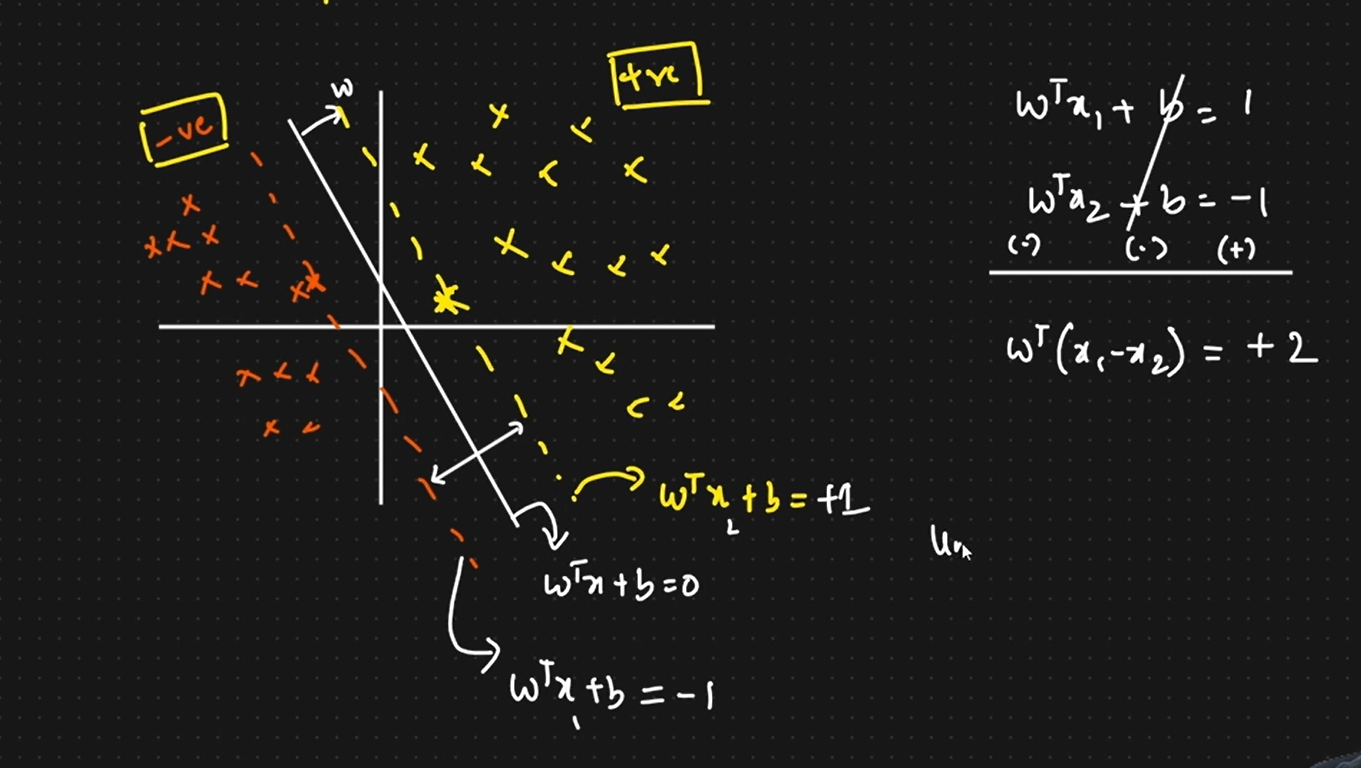


Subtracting these equations yields the vector distance equation $w^T(x_1 - x_2) = 2$. Normalizing by the magnitude of $w$ gives the exact total margin width:

$$\text{Margin Width} = \frac{2}{\|w\|}$$

### The Optimization Problem
To find the safest boundary, we must maximize this margin width $\frac{2}{\|w\|}$, which is mathematically equivalent to minimizing its reciprocal components:

$$\min_{w, b} \frac{\|w\|}{2}$$

$$\text{Subject to the constraint: } y_i(w^Tx_i + b) \ge 1 \quad \forall i$$

Where $y_i \in \{-1, +1\}$ represents the actual class label. For all correctly classified points, this constraint holds true.


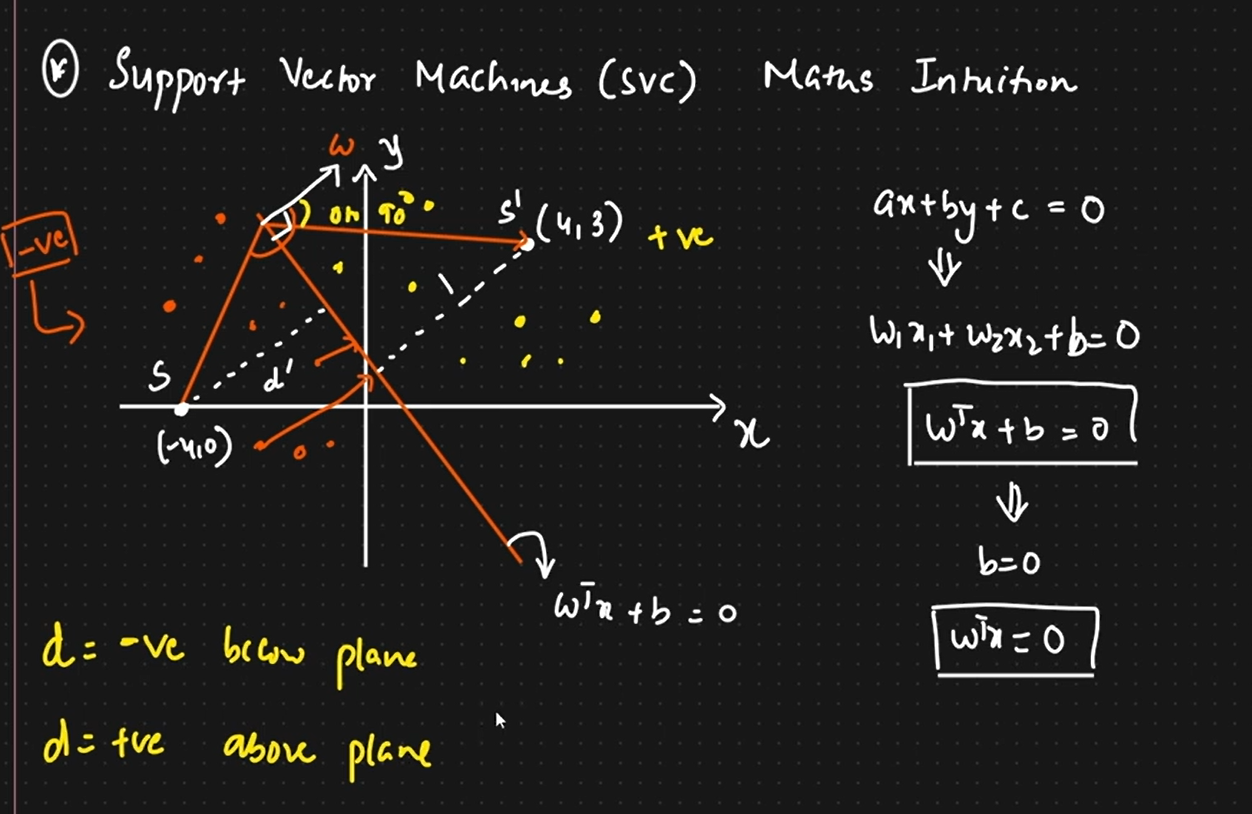



## 4. Soft Margin SVM & The Cost Function

Perfect linear separation is rarely possible in real-world datasets due to overlapping distributions and noise. A Hard Margin approach would fail or overfit drastically.

To handle overlapping data, we transition to a **Soft Margin SVM** by introducing a penalty system using slack variables ($\xi_i$) and a regularization hyperparameter ($C$).

### The Complete Optimization Objective (Cost Function)

$$\min_{w, b} \left( \frac{\|w\|}{2} + C \sum_{i=1}^{n} \xi_i \right)$$

This cost function consists of two competing terms:
* **Margin Maximization Term** ($\frac{\|w\|}{2}$): Tries to keep the margin as wide as possible.
* **Hinge Loss Term** ($C \sum_{i=1}^{n} \xi_i$): Quantifies errors and margin violations.
* **$\xi_i$ (Slack variable):** Measures the proportional distance of an incorrect or violating data point from its correct marginal plane.
* **$\sum_{i=1}^{n} \xi_i$:** The summation of distances of all misclassified or boundary-violating points.

### Understanding the Hyperparameter $C$
The value of $C$ dictates how strictly the algorithm avoids misclassifications:
* **High $C$:** Heavy penalty on misclassifications. The model acts like a Hard Margin SVM, focusing on keeping errors low at the expense of a narrower margin (High risk of overfitting).
* **Low $C$:** Tolerates more boundary violations to achieve a wider margin, prioritizing better generalizability (High risk of underfitting).


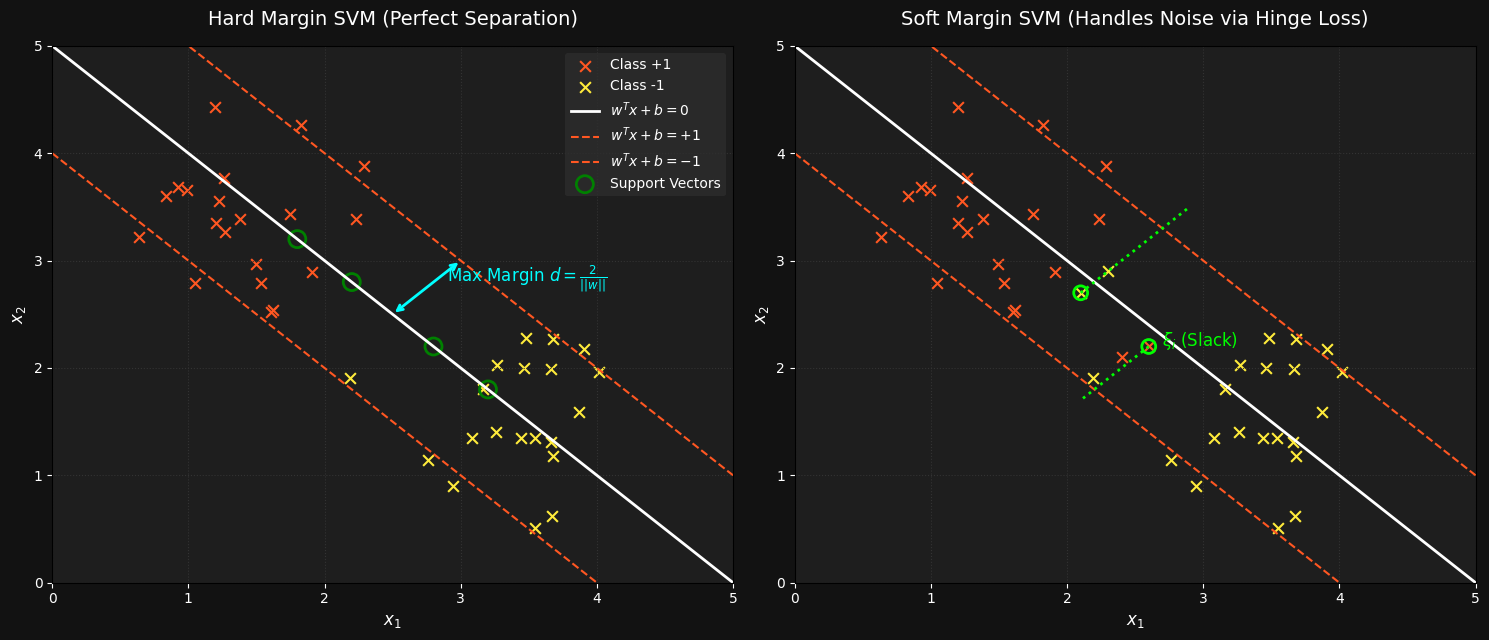


# Support Vector Regression (SVR)

## 1. Geometric Intuition & Basic Terminology

Unlike traditional Support Vector Classifiers (SVC) that try to find a hyperplane separating data classes, Support Vector Regression (SVR) attempts to fit a hyperplane that encloses as many data points as possible within a specified distance metric.

Instead of maximizing the margin between two distinct classes, SVR defines a bounding tube (or envelope) around its regression prediction line.

* **SVR Hyperplane (Prediction Line):** The central regression line defined as $w^Tx + b$.
* **$\epsilon$ (Epsilon-Insensitive Tube):** A tube created by adding and subtracting an error threshold ($\epsilon$) from the hyperplane.
    * **Upper Boundary Line:** $w^Tx + b + \epsilon$
    * **Lower Boundary Line:** $w^Tx + b - \epsilon$
* **Epsilon ($\epsilon$):** Represents the marginal error. Any data point falling inside this tube incurs zero penalty or loss. SVR simply ignores errors smaller than $\epsilon$.
* **Slack Variables ($\xi_i$ and $\xi_i^*$):** Points that fall outside the $\epsilon$-insensitive tube are considered errors. The distance from the boundary of the tube to these external points is measured by slack variables ($\xi_i$ for points above, $\xi_i^*$ for points below).


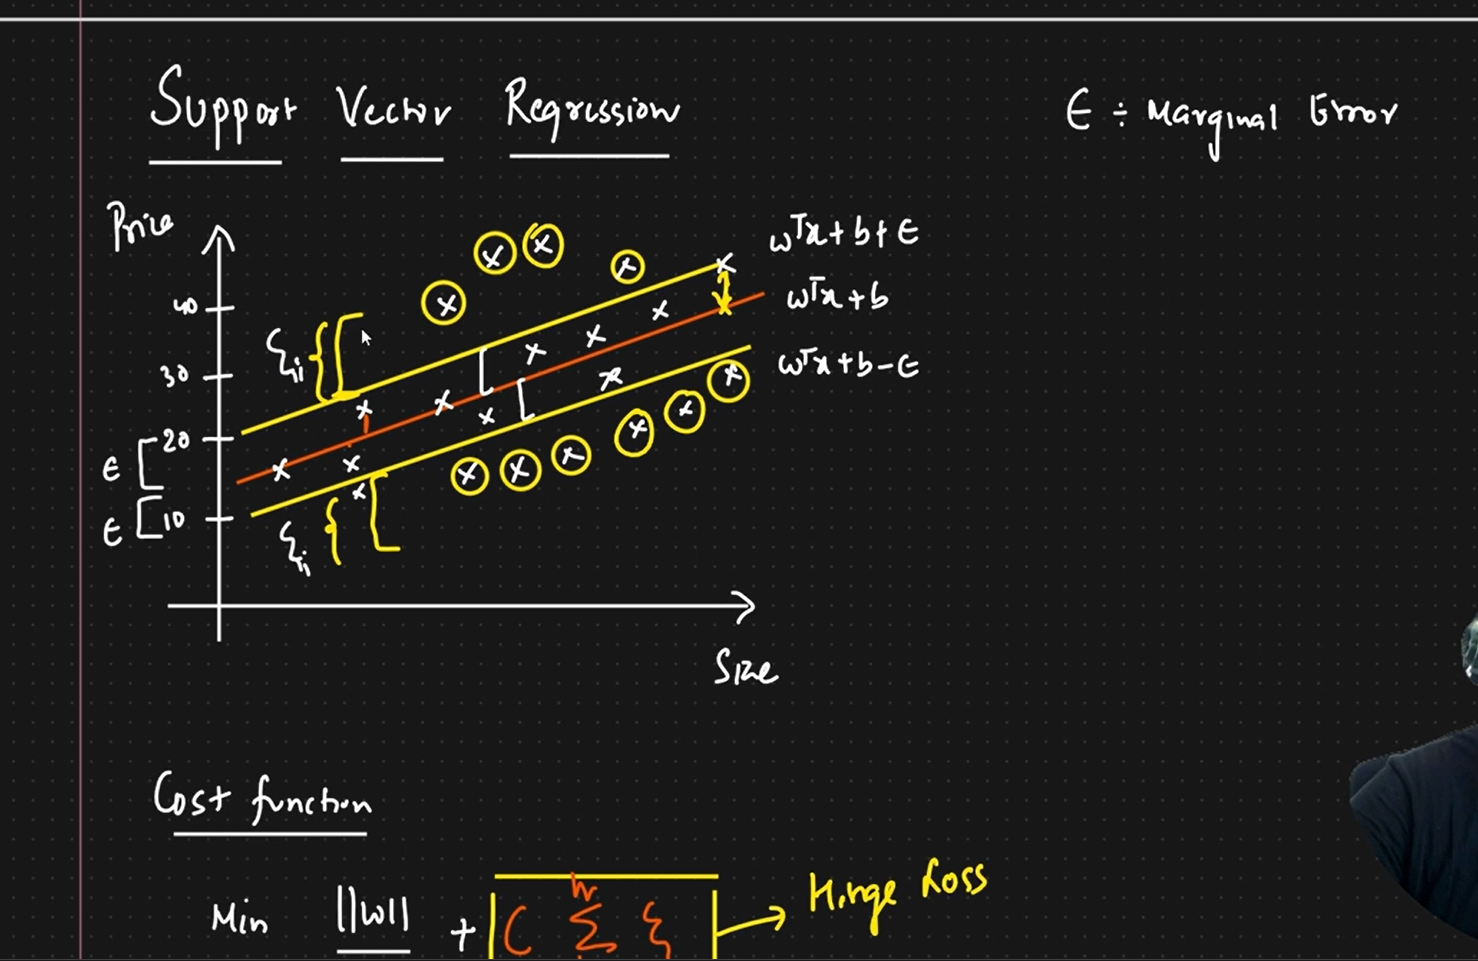



## 2. Cost Function and Constraints

The objective of SVR is to find a flat, generalized function that fits the trend without letting the prediction errors outside the tube become too large.

### The Complete Optimization Objective

$$\min_{w, b} \left( \frac{\|w\|}{2} + C \sum_{i=1}^{n} (\xi_i + \xi_i^*) \right)$$

This objective function balances two elements:
* **Flatness/Regularization ($\frac{\|w\|}{2}$):** Minimizing the norm of $w$ keeps the regression function as flat and smooth as possible to prevent overfitting.
* **Hinge Loss Optimization ($C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$):** Quantifies the penalty for points that cross outside the tube boundaries.

### Optimization Constraints
For every data point $(x_i, y_i)$, the absolute deviation between its true value $y_i$ and its predicted value $w^Tx_i + b$ must stay within the boundary of the tube plus its allowed slack:

$$\text{Subject to: } \begin{cases} y_i - (w^Tx_i + b) \le \epsilon + \xi_i \\ (w^Tx_i + b) - y_i \le \epsilon + \xi_i^* \\ \xi_i, \xi_i^* \ge 0 \end{cases}$$

* **Inside the tube:** $\implies \xi_i, \xi_i^* = 0$
* **Outside the tube:** $\implies \xi_i \text{ or } \xi_i^* > 0$ (proportional to its distance from the tube boundary).


## 3. Impact of Hyperparameters

### Hyperparameter $C$
The hyperparameter $C$ serves as a regularization tuning knob determining the tradeoff between the flatness of the model and its tolerance for points outside the $\epsilon$-tube.

* **High $C$ ($C \uparrow$):** The algorithm heavily penalizes errors outside the tube. The optimization prioritizes minimizing the Hinge Loss term, forcing the total loss function downward. This can lead to a less smooth, potentially overfitted line.
* **Low $C$ ($C \downarrow$):** The model is highly tolerant of data points slipping outside the tube, prioritizing a smoother, flat, and well-generalized global trend line.

### Hyperparameter $\epsilon$
* **High $\epsilon$:** Creates a wider tube. More points fall inside, resulting in fewer support vectors and a more generalized model.
* **Low $\epsilon$:** Creates a narrower tube. Fewer points fit inside, forcing the model to use more support vectors to match the data closely, which increases the risk of overfitting.
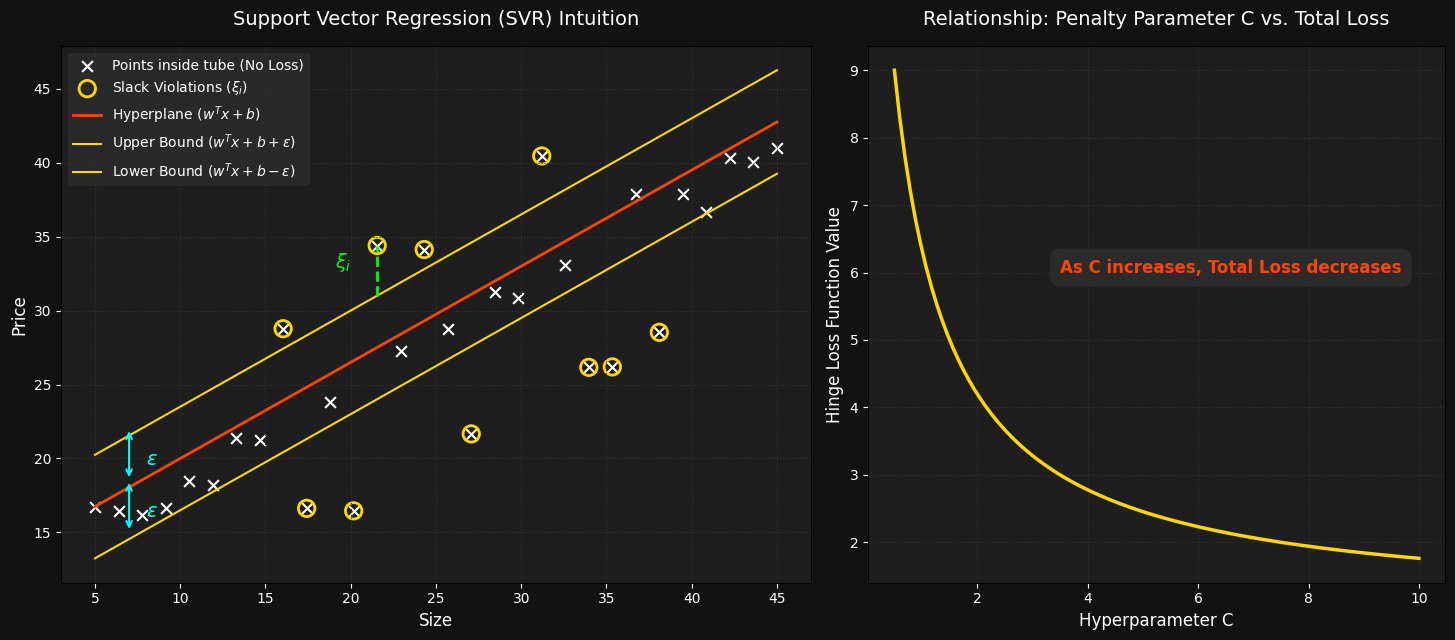







# Support Vector Machine (SVM)

## 1. The Problem: Linearly Inseparable Data
Standard SVM (Linear SVC) works flawlessly when data points can be cleanly divided by a straight line (in 2D) or a plane (in higher dimensions). However, real-world data is frequently non-linear.

Consider a **concentric circle** or ring pattern where one class entirely surrounds another. If you attempt to draw a standard straight decision boundary through this dataset, it is mathematically impossible to separate them properly, resulting in a dramatic drop in model accuracy ($\text{Accuracy} \downarrow\downarrow$).



## 2. The Solution: The Kernel Trick
When data is inseparable in its original low-dimensional feature space, we use **SVM Kernels** to project the data into a higher-dimensional space where a linear boundary *can* separate them.



### Intuition (1D to 2D Example)
Imagine a 1D dataset where points are clustered along a single line, mixed together such that no single cut can split them.
* By applying a transformation formula like $y = x^2$, we project the 1D points into a **2D space**.
* The data points shift to form a clear parabola.
* In this new 2D space, a simple, straight linear line can now effortlessly split the classes, causing model accuracy to jump ($\text{Accuracy} \uparrow\uparrow$).

### Applying to 2D Data
For our 2D concentric circles, a kernel function adds a third dimension ($z$-axis) based on distance from the center. This pushes one class upward while leaving the other at the bottom, creating a **3D space**.
* In 3D, a flat, linear **hyperplane** (a separation plane) cuts cleanly between the two groups.
* When this flat 3D plane is projected back down into our original 2D workspace, it manifests as a complex, curved circle.



## 3. Core Types of SVM Kernels
Depending on the distribution shape of your data, different mathematical kernels can be swapped in:

| Kernel Type | Best Applied To | Visual Decision Boundary in 2D |
| :--- | :--- | :--- |
| **Linear** | Linearly separable data patterns. | Straight line / Flat plane |
| **Polynomial** | Data exhibiting distinct curved or geometric tracks. | Complex polynomial curves |
| **RBF (Radial Basis Function)** | Concentric circles, nested structures, or overlapping blobs. | Closed circles or looping blob-like shapes |
| **Sigmoid** | Neural network-like structures. | S-shaped continuous sweeping curves |


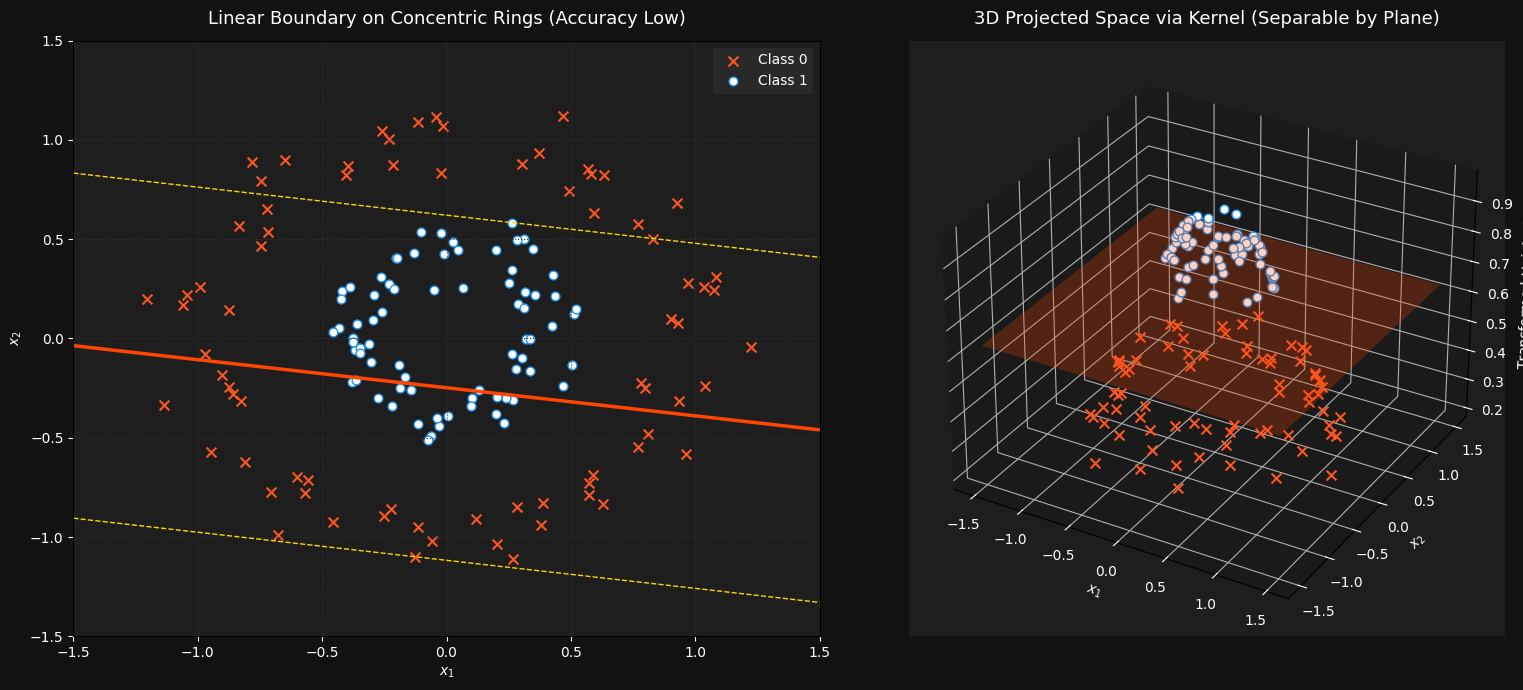



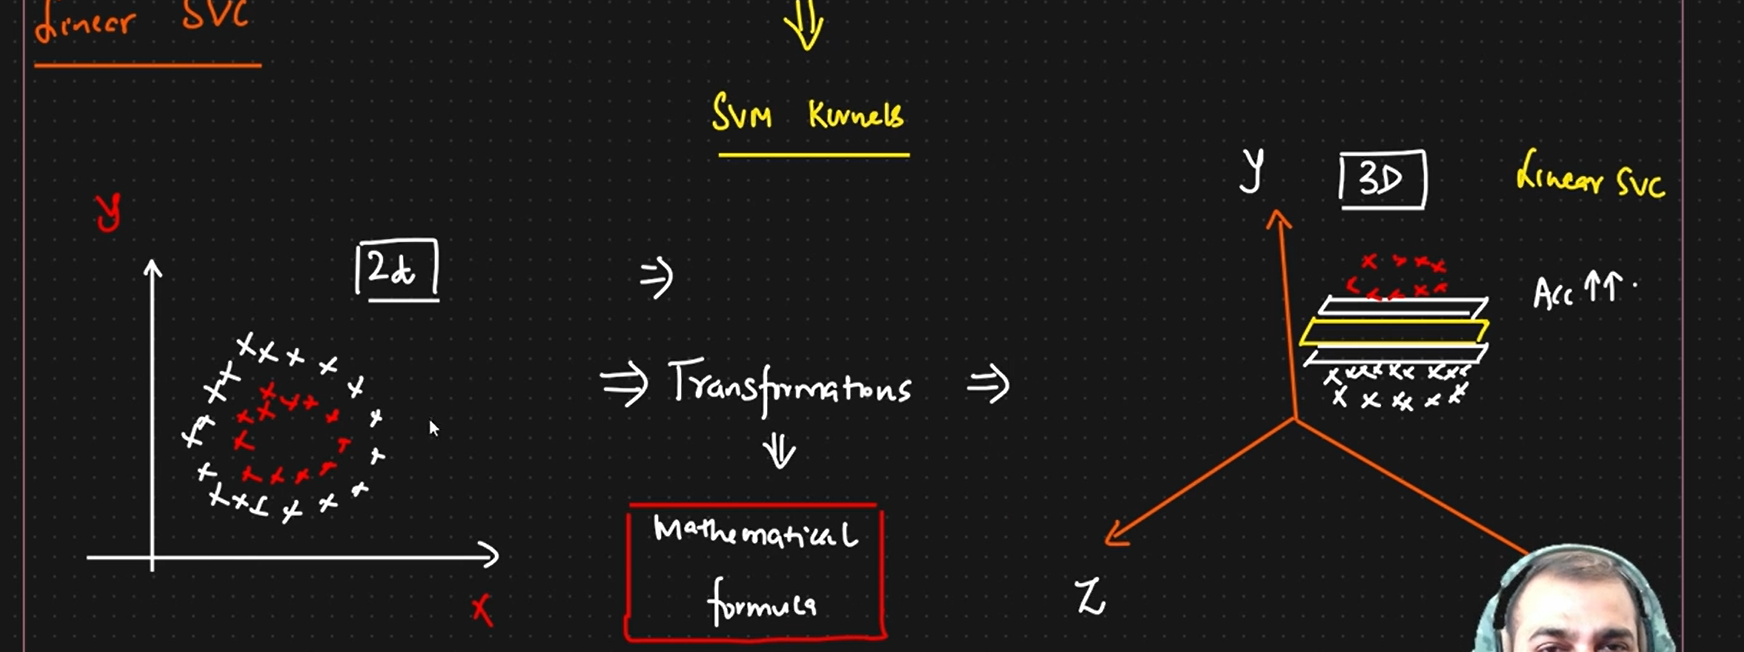